# Customer Churn Prediction Notebook

uhh this is my notebook for churn prediction. i followed some steps and put the screenshots in outputs folder. dataset is expected in data/churn.csv

In [43]:

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
print("libs imported")


libs imported


In [9]:

# Step 2: Load dataset (place your file as data/churn.csv)
data = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [7]:
(data.head())


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
data.shape

(7043, 21)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
# Check for missing values
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
# Check for duplicate records
data.duplicated().sum()

np.int64(0)

In [14]:
# Display statistical summary of numerical columns
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


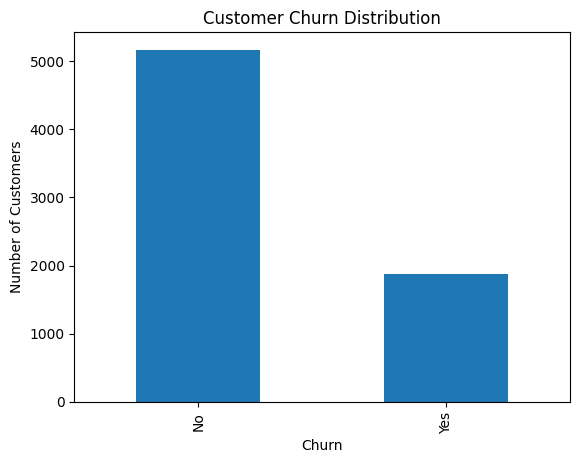

In [15]:
# Display the distribution of the target variable

data["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.show()

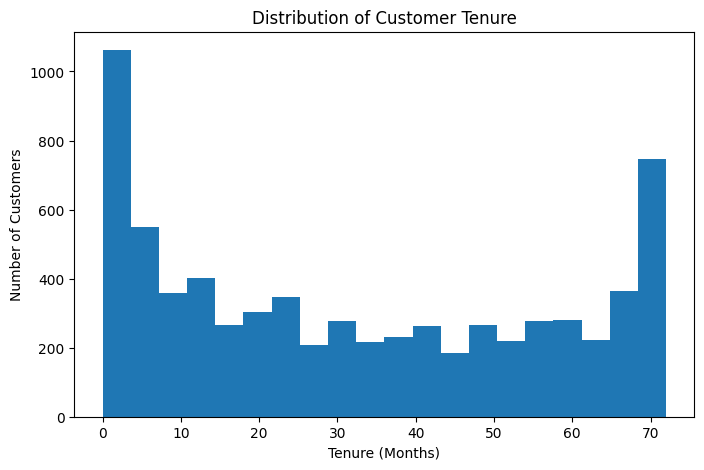

In [16]:
# Distribution of Customer Tenure

plt.figure(figsize=(8,5))

plt.hist(data["tenure"], bins=20)

plt.title("Distribution of Customer Tenure")

plt.xlabel("Tenure (Months)")

plt.ylabel("Number of Customers")

plt.show()

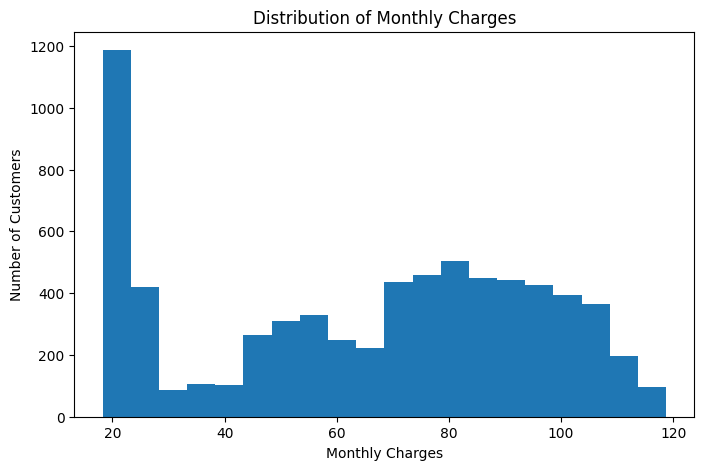

In [17]:
# Distribution of Monthly Charges

plt.figure(figsize=(8,5))

plt.hist(data["MonthlyCharges"], bins=20)

plt.title("Distribution of Monthly Charges")

plt.xlabel("Monthly Charges")

plt.ylabel("Number of Customers")

plt.show()

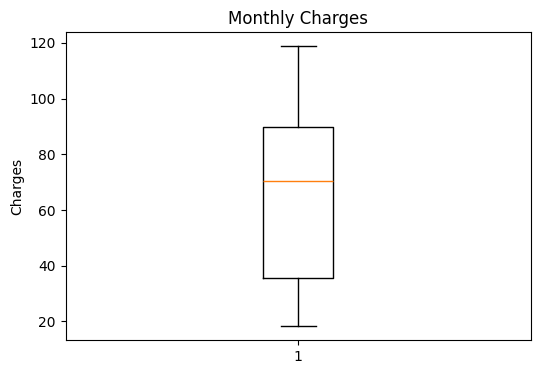

In [18]:
# Box Plot of Monthly Charges

plt.figure(figsize=(6,4))

plt.boxplot(data["MonthlyCharges"])

plt.title("Monthly Charges")

plt.ylabel("Charges")

plt.show()

In [19]:
# Churn by Senior Citizen

pd.crosstab(data["SeniorCitizen"], data["Churn"])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


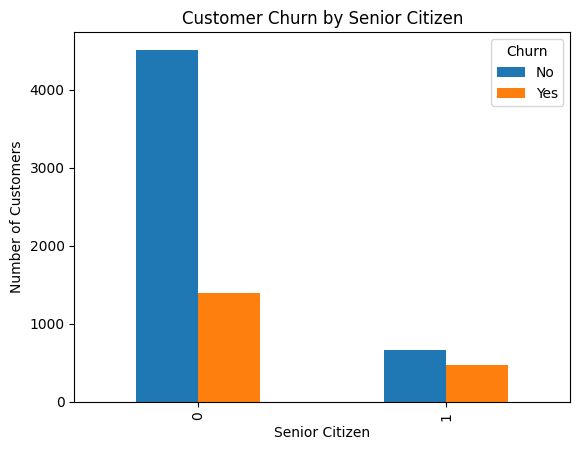

In [20]:
# Churn by Senior Citizen

pd.crosstab(data["SeniorCitizen"], data["Churn"]).plot(kind="bar")

plt.title("Customer Churn by Senior Citizen")

plt.xlabel("Senior Citizen")

plt.ylabel("Number of Customers")

plt.show()

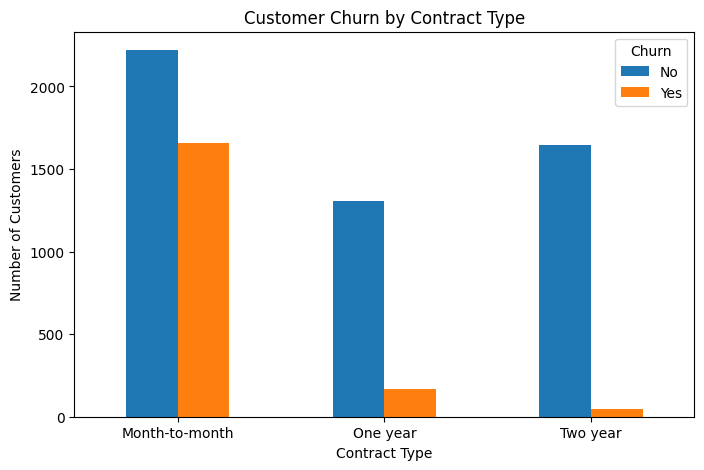

In [21]:
# Churn by Contract Type

pd.crosstab(data["Contract"], data["Churn"]).plot(kind="bar", figsize=(8,5))

plt.title("Customer Churn by Contract Type")

plt.xlabel("Contract Type")

plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

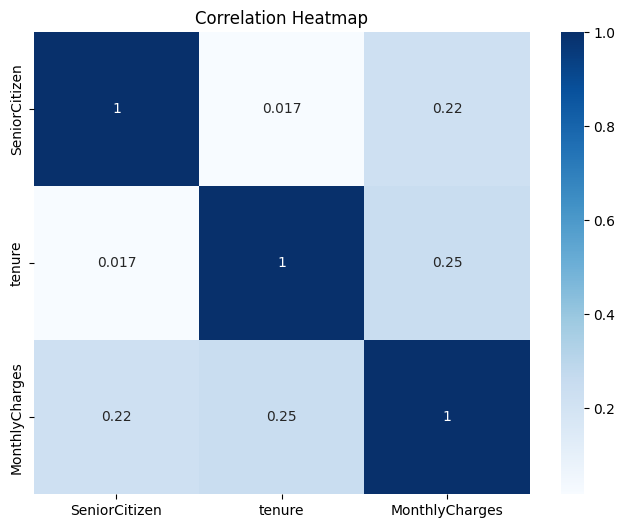

In [23]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:

# Step 3: Preprocessing
data = data.dropna()

data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

data = data.dropna()

le = LabelEncoder()

categorical_columns = data.select_dtypes(include="object").columns

for column in categorical_columns:
    data[column] = le.fit_transform(data[column])

X = data[[
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "Contract",
    "MonthlyCharges",
    "TotalCharges"
]]
y = data["Churn"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [30]:

# Step 4: Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 5625
Testing samples: 1407


In [31]:

# Step 5: Train model
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)


In [33]:
print("Accuracy:", accuracy_score(y_test, log_pred))

Accuracy: 0.7867803837953091


In [32]:
print(confusion_matrix(y_test, log_pred))

[[922 111]
 [189 185]]


In [34]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [36]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7299218194740583


In [37]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7860696517412935


In [44]:
joblib.dump(rf_model, "model.pkl")

['model.pkl']

In [45]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [38]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.786780
1,Decision Tree,0.729922
2,Random Forest,0.786070


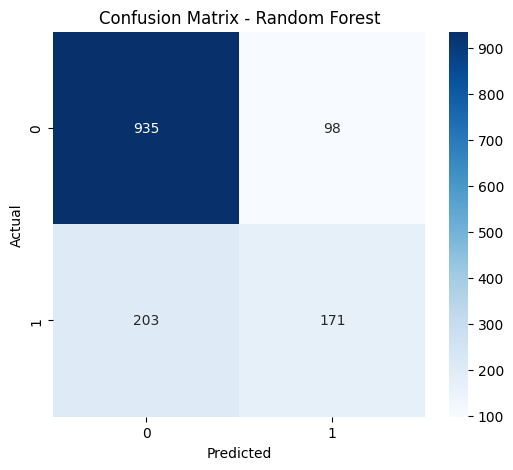

In [39]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [41]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
19,TotalCharges,0.152603
18,MonthlyCharges,0.149936
5,tenure,0.136431
0,customerID,0.126720
15,Contract,0.085540
9,OnlineSecurity,0.044376
17,PaymentMethod,0.043136
12,TechSupport,0.036093
8,InternetService,0.023598
10,OnlineBackup,0.023139


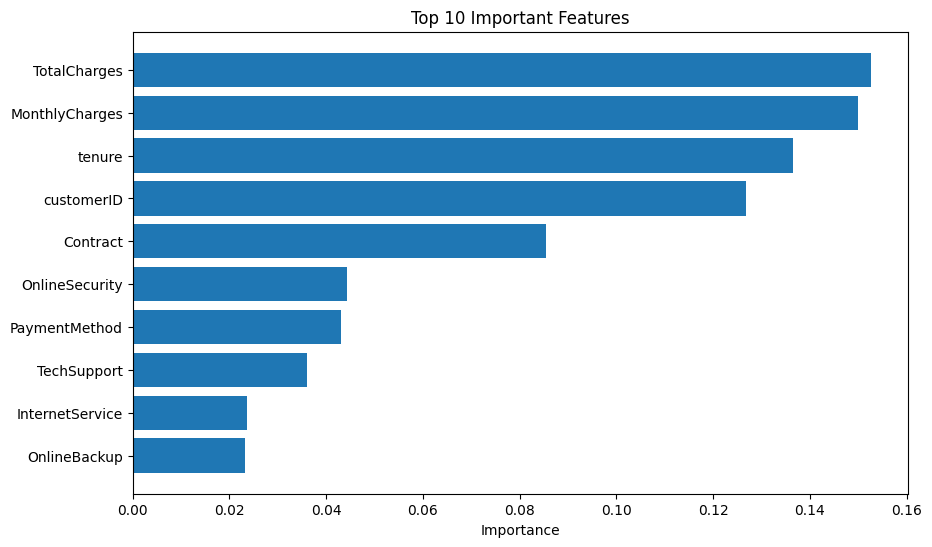

In [42]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

## End

thats all, check outputs folder for screenshots i attached separately.